In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the normalized data
file_path = "/home/rounak/CODE/Low_Engagement_Detection/Data_preprocess/Preprocess_Signals/2_Normalized_data/1.normalized.csv"
df = pd.read_csv(file_path)

# Preview the data
df.head()


,video_id,timestamp,GSR,HR,P_id
0,1,1.751711e+12,0.666667,0.230769,1
1,1,1.751711e+12,0.416667,0.269231,1
2,1,1.751711e+12,0.416667,0.230769,1
3,1,1.751711e+12,0.250000,0.307692,1
4,1,1.751711e+12,0.416667,0.153846,1


In [2]:
# Check basic structure and missing values
df.info()
print("\nMissing values:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33800 entries, 0 to 33799
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   video_id   33800 non-null  int64  
 1   timestamp  33800 non-null  float64
 2   GSR        33800 non-null  float64
 3   HR         33800 non-null  float64
 4   P_id       33800 non-null  int64  
dtypes: float64(3), int64(2)
memory usage: 1.3 MB

Missing values:
 video_id     0
timestamp    0
GSR          0
HR           0
P_id         0
dtype: int64


In [3]:
df.isnull().sum()

video_id     0
timestamp    0
GSR          0
HR           0
P_id         0
dtype: int64

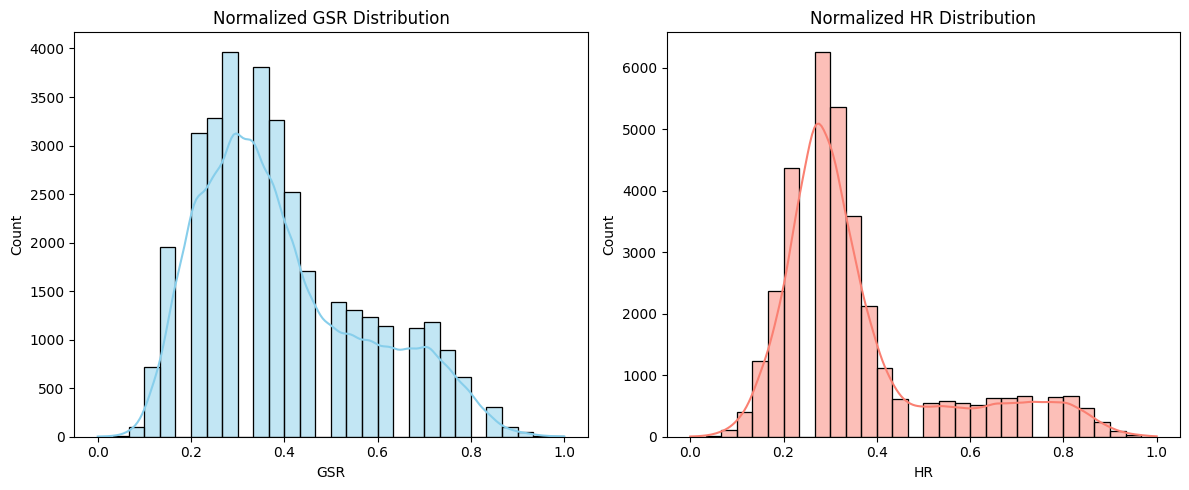

In [4]:
# Plot the distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['GSR'], kde=True, bins=30, color='skyblue')
plt.title('Normalized GSR Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['HR'], kde=True, bins=30, color='salmon')
plt.title('Normalized HR Distribution')

plt.tight_layout()
plt.show()


Unique video IDs: [1 2 3 4 5 6 7 8]


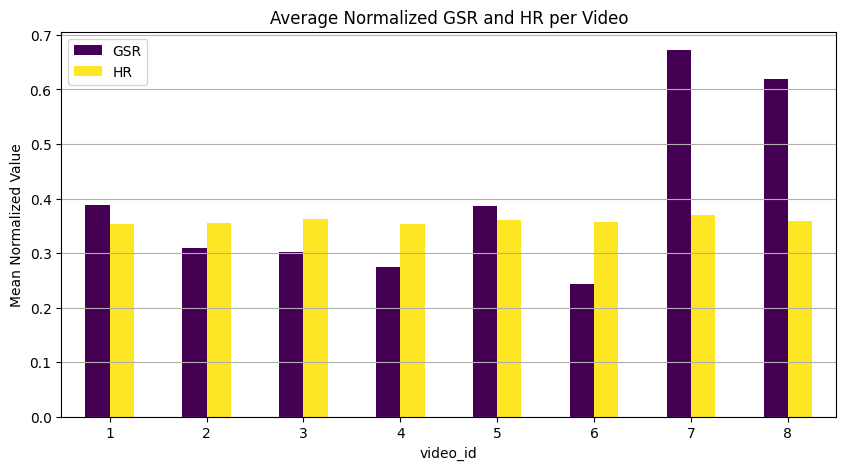

In [5]:
# Check if multiple video IDs exist
print("Unique video IDs:", df["video_id"].unique())

# Plot average signals per video
grouped = df.groupby("video_id")[["GSR", "HR"]].mean()
grouped.plot(kind="bar", figsize=(10, 5), colormap="viridis")
plt.title("Average Normalized GSR and HR per Video")
plt.ylabel("Mean Normalized Value")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


In [8]:
v = 1  # or any other video ID you want to inspect

temp_data = pd.read_csv("/home/rounak/CODE/Low_Engagement_Detection/Data_preprocess/Preprocess_Signals/2_Normalized_data/1.normalized.csv")
index = temp_data["video_id"] == v
original_data = temp_data[index]
data = original_data[['GSR', 'HR']]


In [10]:
import pandas as pd

# Load the normalized data
temp_data = pd.read_csv("/home/rounak/CODE/Low_Engagement_Detection/Data_preprocess/Preprocess_Signals/2_Normalized_data/1.normalized.csv")

# Choose a video ID to analyze
v = 1  # Change this as needed

# Ensure the video_id column is integer for matching
temp_data["video_id"] = temp_data["video_id"].astype(int)

# Filter the data for selected video
index = temp_data["video_id"] == v
original_data = temp_data[index]

print(f"Total rows for video {v}: {len(original_data)}")

# Preview the filtered data
original_data.head(100)


Total rows for video 1: 1769


,video_id,timestamp,GSR,HR,P_id
0,1,1.751711e+12,0.666667,0.230769,1
1,1,1.751711e+12,0.416667,0.269231,1
2,1,1.751711e+12,0.416667,0.230769,1
3,1,1.751711e+12,0.250000,0.307692,1
4,1,1.751711e+12,0.416667,0.153846,1
...,...,...,...,...,...
95,1,1.751711e+12,0.375000,0.230769,1
96,1,1.751711e+12,0.416667,0.307692,1
97,1,1.751711e+12,0.541667,0.192308,1
98,1,1.751711e+12,0.583333,0.269231,1


In [11]:
if len(original_data) >= 50:
    print(f"✅ Enough data for windowing: {len(original_data)} rows (>= 50)")
else:
    print(f"❌ Not enough data for windowing: {len(original_data)} rows (< 50)")


✅ Enough data for windowing: 1769 rows (>= 50)


In [12]:
import numpy as np

data = original_data[['GSR', 'HR']].to_numpy()
window_size = 50

GSR_diff = []
HR_diff = []
GSR_mean = []
HR_mean = []
GSR_var = []
HR_var = []
GSR_baseline_diff = []
HR_baseline_diff = []
percentile_GSRvalue = []
percentile_HRvalue = []

# Simulate the baseline from original function
baseline_slice = temp_data.iloc[600:651]
baseline_GSR = (baseline_slice['GSR'] - baseline_slice['GSR'].min()) / (baseline_slice['GSR'].max() - baseline_slice['GSR'].min())
baseline_HR = (baseline_slice['HR'] - baseline_slice['HR'].min()) / (baseline_slice['HR'].max() - baseline_slice['HR'].min())

GSR_meanblue = baseline_GSR.mean()
HR_meanblue = baseline_HR.mean()

print(f"Baseline GSR_meanblue: {GSR_meanblue:.4f}, HR_meanblue: {HR_meanblue:.4f}")

# Window loop
loop_count = 0
for i in range(0, len(data) - window_size, window_size):
    x = data[i:i + window_size, :]

    # Percentiles
    p75 = np.percentile(x, 75, axis=0)
    percentile_GSRvalue.append(p75[0])
    percentile_HRvalue.append(p75[1])

    # Means
    mean_gsr = x[:, 0].mean()
    mean_hr = x[:, 1].mean()
    GSR_mean.append(mean_gsr)
    HR_mean.append(mean_hr)

    # Variances
    GSR_var.append(x[:, 0].var())
    HR_var.append(x[:, 1].var())

    # Differences from baseline
    GSR_diff.append(abs(GSR_meanblue - mean_gsr))
    HR_diff.append(abs(HR_meanblue - mean_hr))
    GSR_baseline_diff.append(abs(GSR_meanblue - mean_gsr))  # Same as GSR_diff
    HR_baseline_diff.append(abs(HR_meanblue - mean_hr))  # Same as HR_diff

    loop_count += 1

print(f"\n✅ Total windows processed: {loop_count}")
print(f"Sample GSRmean_diff values: {GSR_diff[:5]}")
print(f"Sample HRmean_diff values: {HR_diff[:5]}")


Baseline GSR_meanblue: 0.4853, HR_meanblue: 0.3211

✅ Total windows processed: 35
Sample GSRmean_diff values: [np.float64(0.06112745098039213), np.float64(0.06612745098039213), np.float64(0.05196078431372553), np.float64(0.06862745098039219), np.float64(0.07362745098039208)]
Sample HRmean_diff values: [np.float64(0.009690799396681604), np.float64(0.012767722473604748), np.float64(0.016613876319758636), np.float64(0.1081523378582201), np.float64(0.014306184012066292)]


In [13]:
new_window = pd.DataFrame()
new_window["GSR_mean"] = GSR_mean
new_window["GSR_variance"] = GSR_var
new_window["HR_mean"] = HR_mean
new_window["HR_variance"] = HR_var
new_window["75_percentile_GSR"] = percentile_GSRvalue
new_window["75_percentile_HR"] = percentile_HRvalue
new_window["GSRmean_persen_diff"] = GSR_baseline_diff
new_window["HRmean_persent_diff"] = HR_baseline_diff
new_window["GSRmean_diff"] = GSR_diff
new_window["HRmean_diff"] = HR_diff

# Add static columns to simulate original function
new_window["valence_acc_video"] = 1
new_window["arousal_acc_video"] = 1
new_window["P_id"] = 1
new_window["video_id"] = v

# Save temporarily to inspect
test_save_path = "test_window_features.csv"
new_window.to_csv(test_save_path, index=False)
print(f"Saved to {test_save_path}")


Saved to test_window_features.csv
